In [29]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [30]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    nfours:int
    nsixes:int
    
    sr:float
    bpb:float
    boundary_per:float
    summary:str

In [31]:
def calculate_sr(state:BatsmanState):
    sr=(state['runs']/state['balls'])*100
    return {'sr':sr}

In [32]:
def calculate_bpb(state:BatsmanState):
    bpb=state['balls']/(state['nfours']+state['nsixes'])
    return {'bpb':bpb}

In [33]:
def calculate_boundary_per(state:BatsmanState):
    boundary_per=(((state['nfours']*4)+ (state['nsixes']*6))/state['runs'])*100
    return {'boundary_per':boundary_per}

In [34]:
def summary(state:BatsmanState):
    summary=f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_per']}  
"""
    return {'summary':summary}

In [35]:
graph=StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_per',calculate_boundary_per)
graph.add_node('summary',summary)

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_per')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundary_per','summary')

graph.add_edge('summary',END)


workflow=graph.compile()



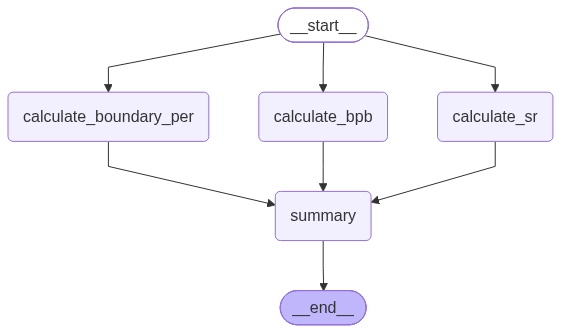

In [36]:
workflow

In [37]:
initial_state={
    'runs':150,
    'balls':48,
    'nfours':8,
    'nsixes':14
}

final_result=workflow.invoke(initial_state)

In [38]:
final_result

{'runs': 150,
 'balls': 48,
 'nfours': 8,
 'nsixes': 14,
 'sr': 312.5,
 'bpb': 2.1818181818181817,
 'boundary_per': 77.33333333333333,
 'summary': '\nStrike Rate - 312.5 \n\nBalls per boundary - 2.1818181818181817 \n\nBoundary percent - 77.33333333333333  \n'}

In [39]:
final_result['sr']

312.5

In [40]:
final_result['bpb']

2.1818181818181817

In [41]:
final_result['boundary_per']

77.33333333333333

In [42]:
print(final_result['summary'])


Strike Rate - 312.5 

Balls per boundary - 2.1818181818181817 

Boundary percent - 77.33333333333333  

